In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import numpy as np

from datetime import datetime
from time import time

# Enable 64-bit by default for torch
torch.set_default_dtype(torch.float64)

import mnist_vae

In [2]:
usps_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

usps_test_ds = datasets.USPS(
    root="../datasets",
    train=False,
    download=True,
    transform=usps_transform,
)
usps_train_ds = datasets.USPS(
    root="../datasets",
    train=True,
    download=True,
    transform=usps_transform,
)

usps_loader = DataLoader(
    usps_test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
usps_train_loader = DataLoader(
    usps_train_ds,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

print(f"USPS test samples: {len(usps_test_ds)}")

USPS test samples: 2007


## Training VAE

In [3]:
# Train the VAE
encoder, decoder = mnist_vae.train_vae(usps_train_loader, epochs=20, lr=1e-3)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20  avg loss/example: 375.5568
Epoch 2/20  avg loss/example: 346.0021
Epoch 3/20  avg loss/example: 330.6339
Epoch 4/20  avg loss/example: 323.6955
Epoch 5/20  avg loss/example: 317.6533
Epoch 6/20  avg loss/example: 312.2408
Epoch 7/20  avg loss/example: 309.2582
Epoch 8/20  avg loss/example: 307.4874
Epoch 9/20  avg loss/example: 306.3038
Epoch 10/20  avg loss/example: 304.9052
Epoch 11/20  avg loss/example: 302.4682
Epoch 12/20  avg loss/example: 299.5921
Epoch 13/20  avg loss/example: 298.2096
Epoch 14/20  avg loss/example: 296.6343
Epoch 15/20  avg loss/example: 295.5079
Epoch 16/20  avg loss/example: 294.7113
Epoch 17/20  avg loss/example: 293.9033
Epoch 18/20  avg loss/example: 293.0427
Epoch 19/20  avg loss/example: 292.3918
Epoch 20/20  avg loss/example: 292.4947


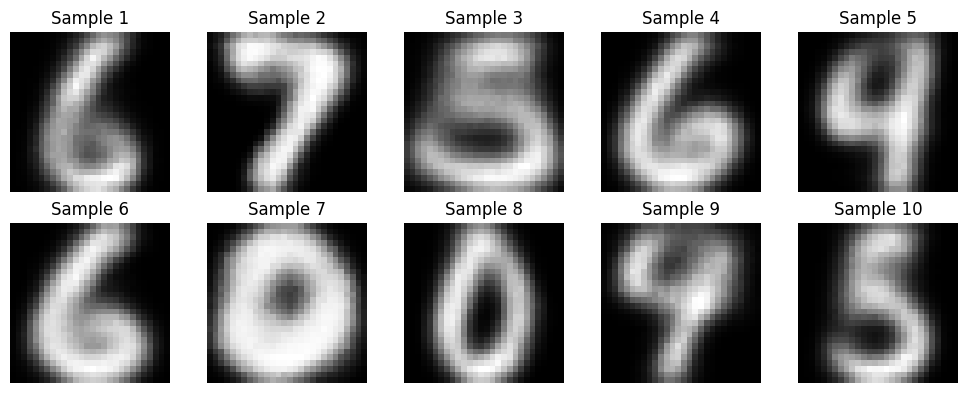

In [4]:
import matplotlib.pyplot as plt

decoder.eval()

num_samples = 10
latent_dim = decoder.fc1.in_features  # 20 for this model

with torch.no_grad():
    z = torch.randn(num_samples, latent_dim)
    generated = decoder(z).view(num_samples, 28, 28).cpu().numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap="gray")
    ax.axis("off")
    ax.set_title(f"Sample {i+1}")

plt.tight_layout()
plt.show()

In [6]:
# Save the models (just in case)
import os
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)
torch.save(encoder.state_dict(), os.path.join(model_dir, "mnist_vae_ood_encoder.pth"))
torch.save(decoder.state_dict(), os.path.join(model_dir, "mnist_vae_ood_decoder.pth"))

## Using VAE for Attack

In [3]:
# Load the models (just to verify)
import os
model_dir = "saved_models"
encoder_loaded = mnist_vae.Encoder()
decoder_loaded = mnist_vae.Decoder()
encoder_loaded.load_state_dict(torch.load(os.path.join(model_dir, "mnist_vae_ood_encoder.pth")))
decoder_loaded.load_state_dict(torch.load(os.path.join(model_dir, "mnist_vae_ood_decoder.pth")))
encoder_loaded.eval()
decoder_loaded.eval()

Decoder(
  (fc1): Linear(in_features=20, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [4]:
from onnx2pytorch import ConvertModel

import json_to_pytorch

import attack

In [5]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [6]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu_sampled.json", double_precision=True)

In [27]:
adv = attack.VAEAdversary(encoder_loaded, decoder_loaded, attacks_iter=2, attack_restarts=10, attack_epsilon=0.2)

### Sampled Bounds

In [28]:
from torch.utils.data import Subset, DataLoader
subset = Subset(usps_loader.dataset, range(100))
small_loader = DataLoader(subset, batch_size=usps_loader.batch_size,
                          num_workers=usps_loader.num_workers,
                          collate_fn=usps_loader.collate_fn)

In [35]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, usps_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [36]:
robust_eval_results_sampled

{'normal_loss_ref': 0.03156741729246579,
 'normal_loss_test': nan,
 'adv_loss_ref': 0.04069896982684578,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.5710014947683109,
 'normal_acc_test': 0.5241654210264076,
 'adv_acc_ref': 0.44245142002989535,
 'adv_acc_test': 0.3831589436970603,
 'normal_eq': 0.9481813652217239,
 'adv_eq': 0.9342301943198804,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.051818634778276036,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.06576980568011959,
 'total': 2007,
 'adv_examples': [(tensor([[3.2206e-04, 8.1757e-04, 1.6846e-03,  ..., 4.9547e-05, 2.7091e-05,
            1.0786e-05],
           [5.0556e-05, 8.1964e-05, 2.0365e-04,  ..., 7.3029e-04, 4.7654e-04,
            4.2091e-04],
           [1.6843e-02, 4.4739e-02, 8.6326e-02,  ..., 1.2664e-02, 8.6954e-03,
            5.0203e-03],
           ...,
           [3.5978e-04, 1.7648e-03, 3.6583e-03,  ..., 2.7459e-03, 8.4866e-04,
            1.4310e-04],
           [8.0751e-05, 2.5349e-04, 4.2466e-04,  ..., 7.7681e-04,

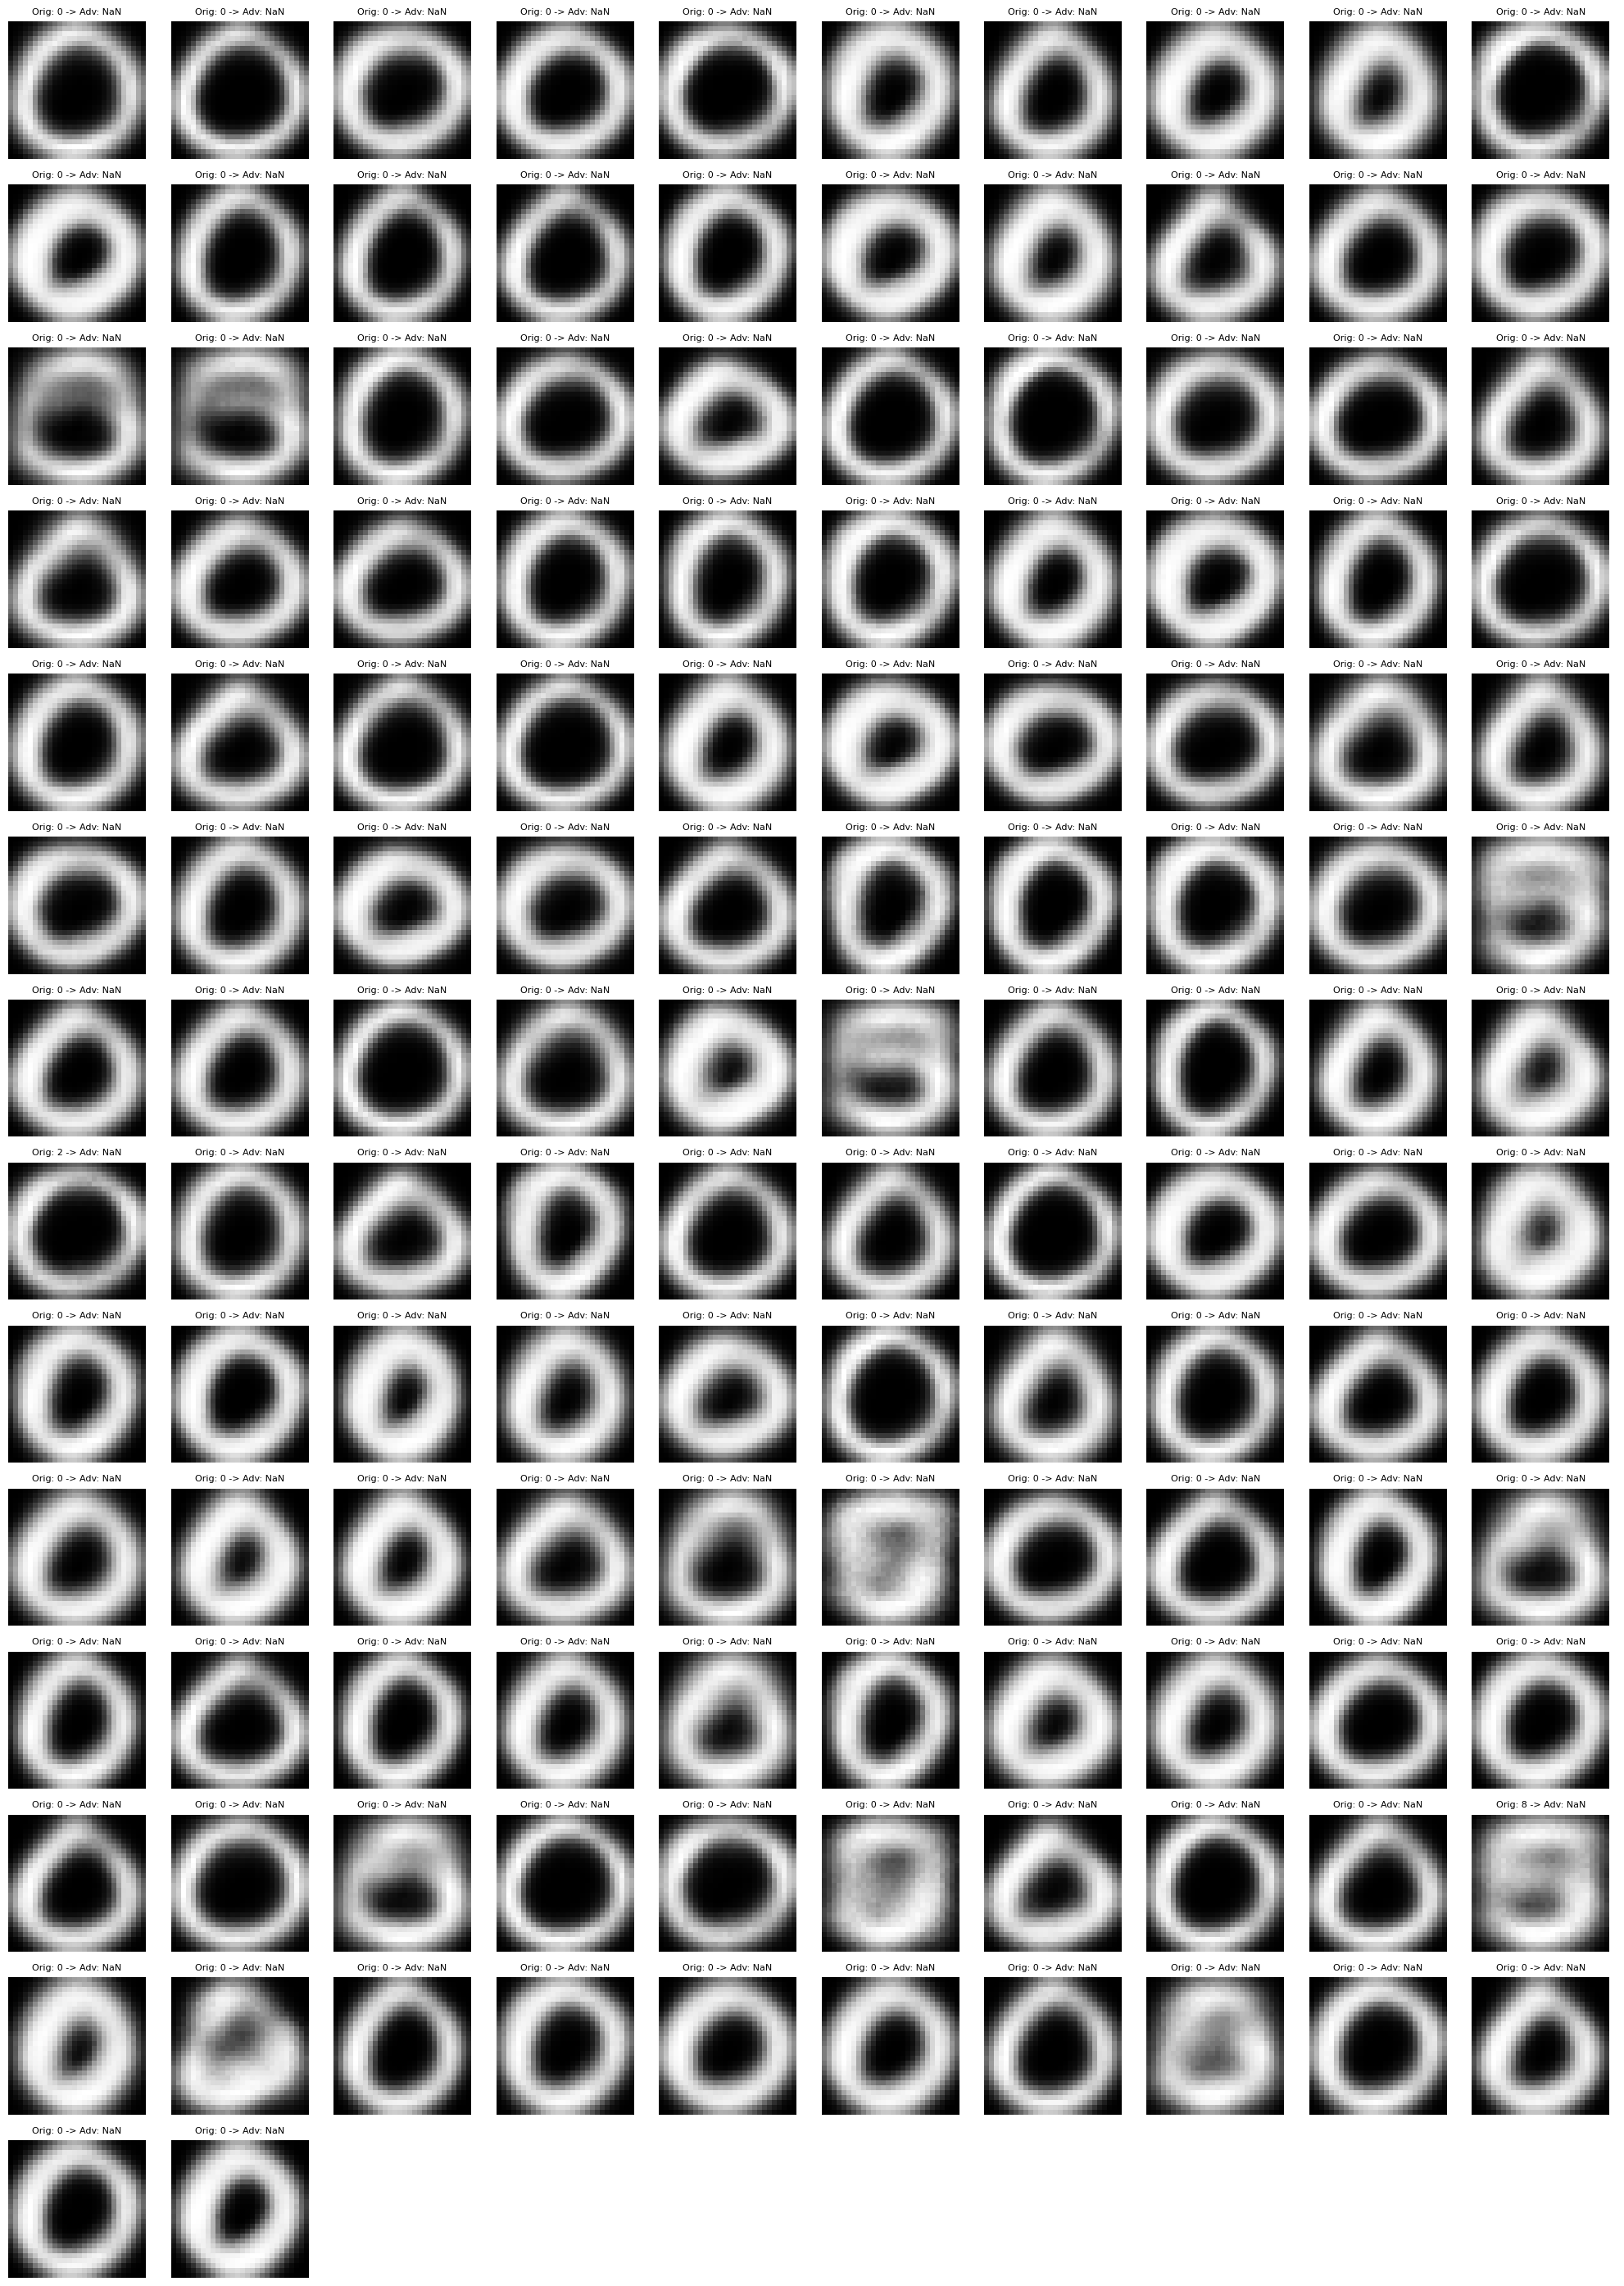

In [40]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

adv_examples = robust_eval_results_sampled["adv_examples"]

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    ncols = 10
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
# Save figure
fig.savefig("mnist_vae_ood_adv_examples_gelu_sampled.png")

## Provable Bounds

In [38]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu.json", double_precision=True)

In [39]:
robust_eval_results = attack.robust_eval(reference_model, test_model, usps_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [42]:
robust_eval_results

{'normal_loss_ref': 0.03156741729246579,
 'normal_loss_test': 0.03156740905217437,
 'adv_loss_ref': 0.040364528883403444,
 'adv_loss_test': 0.04036385392888969,
 'normal_acc_ref': 0.5710014947683109,
 'normal_acc_test': 0.5710014947683109,
 'adv_acc_ref': 0.4439461883408072,
 'adv_acc_test': 0.4444444444444444,
 'normal_eq': 1.0,
 'adv_eq': 0.9990034877927254,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.0,
 'total': 2007,
 'adv_examples': [(tensor([[1.9019e-04, 5.2667e-04, 1.0146e-03,  ..., 1.1221e-04, 6.5173e-05,
            2.5203e-05],
           [3.9664e-05, 6.6676e-05, 1.5005e-04,  ..., 4.3632e-04, 3.1887e-04,
            3.1886e-04],
           [4.6286e-03, 1.2078e-02, 2.5016e-02,  ..., 4.6830e-03, 2.4109e-03,
            1.2651e-03],
           ...,
           [4.9976e-04, 2.1742e-03, 4.3599e-03,  ..., 2.8524e-03, 1.0098e-03,
            2.1701e-04],
           [1.5839e-04, 4.3226e-04, 7.4943e-04,  ..., 3.4967e-04, 2.3425e-04,
   

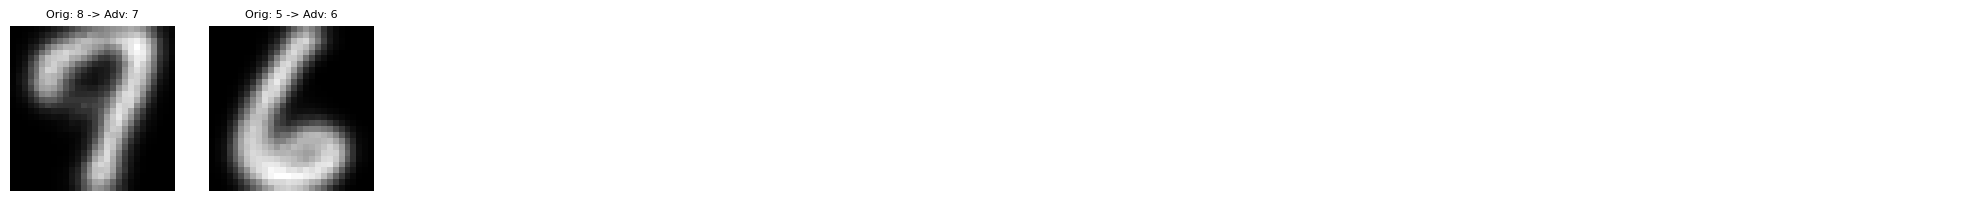

In [44]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

adv_examples = robust_eval_results["adv_examples"]

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model(x)

        changed = (
            (ref.argmax(1) != test.argmax(1))
            | torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        for idx in idxs:
            changed_samples.append(x[idx].view(28, 28).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    ncols = 10
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(n):
        axes[i].imshow(changed_samples[i], cmap="gray")
        axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [45]:
# Save figure
fig.savefig("mnist_vae_ood_adv_examples_gelu.png")